In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## Import raw offset use data

In this section, we read in the lasted CARB issuance tables, which has data about project compliance retirements per project-vintage combination. 

In [2]:
rename_issuance = {
    "OPR Project ID": "opr_id",
    "Project Type": "project_type",
    "Vintage": "vintage",
    "ARB Offset Credits Issued": "issuance",
    "Retired 1st Compliance Period (CA)": "compliance_1",
    "Retired 2nd Compliance Period (CA)": "compliance_2",
    "Retired 3rd Compliance Period (CA)": "compliance_3",
    "Retired 4th Compliance Period (CA)": "compliance_4",
    "Retired 5th Compliance Period (CA)": "compliance_5",
}

In [3]:
df_issuance = pd.read_excel('input-data/nc-arboc_issuance.xlsx', sheet_name='ARB Offset Credit Issuance', skiprows=0)
df_issuance = df_issuance[rename_issuance.keys()].rename(columns=rename_issuance)
df_issuance = df_issuance.dropna(subset=['vintage'])
df_issuance['vintage'] = df_issuance['vintage'].astype(int)

In [4]:
df_issuance

,opr_id,project_type,vintage,issuance,compliance_1,compliance_2,compliance_3,compliance_4,compliance_5
0,ACR1007,ODS,2024,79565,0.0,0.0,0.0,79565.0,0.0
1,ACR1009,MMC,2024,31850,0.0,0.0,0.0,0.0,0.0
2,CAR2111,MMC,2025,159383,0.0,0.0,0.0,0.0,0.0
3,ACR1011,MMC,2024,6631,0.0,0.0,0.0,0.0,0.0
4,ACR1013,ODS,2024,92445,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...
2154,CAR730,Forest,2013,324298,0.0,212032.0,0.0,0.0,10830.0
2155,CAR730,Forest,2014,339125,0.0,181733.0,42280.0,0.0,5069.0
2156,CAR393,Livestock,2012,11196,0.0,11196.0,0.0,0.0,0.0
2157,CAR393,Livestock,2013,16645,0.0,16645.0,0.0,0.0,0.0


## Translate credits used into gas volumes

All credit use data is reported in terms of credit counts — and each credit corresponds to 1 tCO2e. To translate that into gas-specific offset project fluxes, we will need to make assumptions on a project type, protocol, or maybe even project-specific basis. 

Method: 
- Forest — assume all credits correspond to a negative CO2 flux, and an efflux corresponding with harvest at the end of the permanence period (100 years)
- MMC — assume all credits correspond to a negative CH4 flux
- Livestock — assume all credits correspond to a negative CH4 flux
- ODS — that all ODS projects translate to CFC-12 reductions; consider project-specific classification

Problems: 
- Obscures the fact that within any project, there is gwp logic happening to net out project emissions 
- Obscures the fact that for some project types, there may be a reduction in multiple gas types

In [6]:
# protocols w/ gwp conversions point to defer to MRR section 95102(a) for specific gwp values. i think that 
# means they should follow the same 2021 switch seen in the MRR data. 

gwp_values_2021_onwards = {
    'co2': 1, 
    'ch4': 25,
    'n2o': 298
}

gwp_values_2020_prior = {
    'co2': 1, 
    'ch4': 21,
    'n2o': 310
}

cfc_12_gwp = 10900 # 2014 ODS protocol (Table B.1); 2011 ODS protocol (Table 5.1)

In [7]:
df_issuance['project_type'].unique()

array(['ODS', 'MMC', 'Forest', 'Livestock'], dtype=object)

In [8]:
# assume all forest credit compliance use translate to CO2 emission reductions

forest_mask = df_issuance['project_type'] == 'Forest'
df_issuance.loc[forest_mask, 'total_credits_used_co2e'] = df_issuance.loc[forest_mask, [f'compliance_{i}' for i in range(1, 6)]].sum(axis=1)
df_issuance.loc[forest_mask, 'co2_flux'] = df_issuance.loc[forest_mask, 'total_credits_used_co2e'] * -1

# assume all forest carbon storage reverses 100 years later 
# TODO: is this the right logic? or is it 100 years from the project start? I always forget... 
reemission_rows = df_issuance[forest_mask][['opr_id', 'project_type', 'vintage', 'co2_flux']].copy()
reemission_rows['vintage'] = reemission_rows['vintage'] + 100
reemission_rows['co2_flux'] = reemission_rows['co2_flux'] * -1

df_issuance = pd.concat([df_issuance, reemission_rows], ignore_index=True)

In [9]:
# assume all MMC credit compliance use translate to CH4 emission reductions

mmc_mask = df_issuance['project_type'] == 'MMC'
df_issuance.loc[mmc_mask, 'total_credits_used_co2e'] = df_issuance.loc[mmc_mask, [f'compliance_{i}' for i in range(1, 6)]].sum(axis=1)
df_issuance.loc[mmc_mask, 'ch4_flux'] = (
    df_issuance.loc[mmc_mask, 'total_credits_used_co2e'] / 
    df_issuance.loc[mmc_mask, 'vintage'].apply(lambda y: gwp_values_2020_prior['ch4'] if y <= 2020 else gwp_values_2021_onwards['ch4'])
) * -1

In [10]:
# assume all Livestock compliance use translate to CH4 emission reductions

livestock_mask = df_issuance['project_type'] == 'Livestock'
df_issuance.loc[livestock_mask, 'total_credits_used_co2e'] = df_issuance.loc[livestock_mask, [f'compliance_{i}' for i in range(1, 6)]].sum(axis=1)
df_issuance.loc[livestock_mask, 'ch4_flux'] = (
    df_issuance.loc[livestock_mask, 'total_credits_used_co2e'] / 
    df_issuance.loc[livestock_mask, 'vintage'].apply(lambda y: gwp_values_2020_prior['ch4'] if y <= 2020 else gwp_values_2021_onwards['ch4'])) * -1

In [11]:
# assume (temporarily) that all ODS projects translate to CFC-12 reductions
# looked at top 10 ODS projects with retirements; ODPR section VI reports "ODS DESTROYED" by mass 
# all projects had a mix of gases, but all had a majority (>95%) CFC-12

# TODO: project level classification using ODPRS? there are only about 300 projects, and eight eligible
# ODS substances to destroy, each will quite distinct GWP, all captured in FaIR (see the 
# 2014 ODS protocol, Section 2.2 and Tables B.1 and B.2)

ods_mask = df_issuance['project_type'] == 'ODS'
df_issuance.loc[ods_mask, 'total_credits_used_co2e'] = df_issuance.loc[ods_mask, [f'compliance_{i}' for i in range(1, 6)]].sum(axis=1)
df_issuance.loc[ods_mask, 'cfc-12_flux'] = (df_issuance.loc[ods_mask, 'total_credits_used_co2e'] / cfc_12_gwp) * -1

## Create offset flux timeseries

Group by year to create timeseries of ghgs that were used to offset the ongoing emissions of regulated entities. 

In [12]:
timeseries_project_fluxes = df_issuance.groupby('vintage')[['ch4_flux', 'co2_flux', 'cfc-12_flux']].sum().reset_index()
timeseries_project_fluxes = timeseries_project_fluxes.rename(columns={'vintage': 'year'})

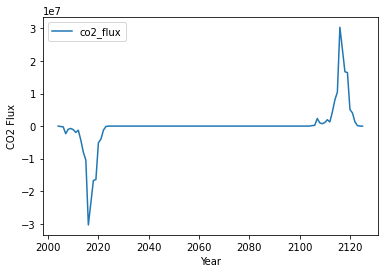

In [13]:
timeseries_project_fluxes.plot(x='year', y='co2_flux')
plt.xlabel('Year')
plt.ylabel('CO2 Flux')
plt.show()

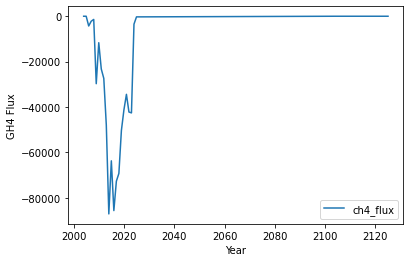

In [14]:
timeseries_project_fluxes.plot(x='year', y='ch4_flux')
plt.xlabel('Year')
plt.ylabel('GH4 Flux')
plt.show()

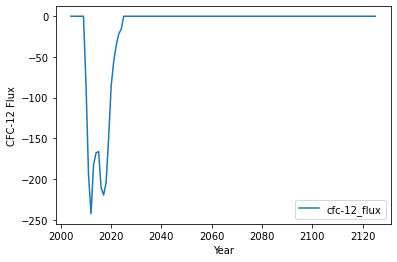

In [15]:
timeseries_project_fluxes.plot(x='year', y='cfc-12_flux')
plt.xlabel('Year')
plt.ylabel('CFC-12 Flux')
plt.show()

In [16]:
# save timeseries as a csv 
timeseries_project_fluxes.to_csv('output-data/timeseries_project_fluxes.csv', index=False)